# Árboles de decisión

Cuestionario 2 de la asignatura Aprendizaje Automatico del Máster Universitario en
Lógica, Computación e Inteligencia Artificial.

Realizado por Manuel Enciso Martínez.

Para este trabajo, hemos utilizado el dataset: Yilmaz, N. & Şekeroğlu, B. (2019). Higher Education Students Performance Evaluation [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C51G82.

In [9]:
from sklearn.tree import DecisionTreeClassifier, export_text, export_graphviz, plot_tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import linear_model
from sklearn import metrics as skm
#from sklearn.feature_selection import VarianceThreshold

import logging
logging.getLogger('matplotlib.font_manager').setLevel(level=logging.CRITICAL) # Para evitar warnings

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from matplotlib.colors import ListedColormap

## 1º Parte

## Procesado de datos

Vamos a cargar el fichero y mostrar los datos.

Esta base de datos no contiene ninguna instancia vacía, por lo que no necesitamos realizar una gestión adicional.

In [2]:

# Cargar el archivo DATA.csv (subido a los archivos locales del google colab)
df = pd.read_csv('/content/DATA.csv')

# Mostrar las primeras 5 filas del DataFrame
display(df.head())

,STUDENT ID,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,COURSE ID,GRADE
0,STUDENT1,2,2,3,3,1,2,2,1,1,...,1,1,3,2,1,2,1,1,1,1
1,STUDENT2,2,2,3,3,1,2,2,1,1,...,1,1,3,2,3,2,2,3,1,1
2,STUDENT3,2,2,2,3,2,2,2,2,4,...,1,1,2,2,1,1,2,2,1,1
3,STUDENT4,1,1,1,3,1,2,1,2,1,...,1,2,3,2,2,1,3,2,1,1
4,STUDENT5,2,2,1,3,2,2,1,3,1,...,2,1,2,2,2,1,2,2,1,1


A continuación proporcionamos la información respecto de las distintas columnas y el signifcado equivalente de los posibles valores a tomar.

| Columna | Nombre | Descripción | Valores |
|---|--------|-------------|---------|
| 1 | Student Age | Rango de edad del estudiante | 1: 18-21, 2: 22-25, 3: 26+ |
| 2 | Sex | Género del estudiante | 1: Femenino, 2: Masculino |
| 3 | High School Type | Tipo de escuela secundaria de la que proviene | 1: Privada, 2: Estatal, 3: Otra |
| 4 | Scholarship Type | Tipo de beca recibida | 1: Ninguna, 2: 25%, 3: 50%, 4: 75%, 5: 100% (Completa) |
| 5 | Additional Work | ¿Trabaja además de estudiar? | 1: Sí, 2: No |
| 6 | Regular Artistic/Sports Activity | ¿Realiza actividades artísticas o deportivas regularmente? | 1: Sí, 2: No |
| 7 | Partner | ¿Tiene pareja? | 1: Sí, 2: No |
| 8 | Total Salary | Salario total disponible (si aplica) | 1: USD 135-200, 2: USD 201-270, 3: USD 271-340, 4: USD 341-410, 5: USD 410+ |
| 9 | Transportation | Medio de transporte a la universidad | 1: Autobús, 2: Auto privado/taxi, 3: Bicicleta, 4: Otro |
| 10 | Accommodation Type | Tipo de alojamiento | 1: Alquilado, 2: Dormitorio, 3: Con familia, 4: Otro |
| 11 | Mother's Education | Nivel educativo de la madre | 1: Primaria, 2: Secundaria, 3: Bachillerato, 4: Universidad, 5: Máster, 6: Doctorado |
| 12 | Father's Education | Nivel educativo del padre | 1: Primaria, 2: Secundaria, 3: Bachillerato, 4: Universidad, 5: Máster, 6: Doctorado |
| 13 | Number of Siblings | Cantidad de hermanos/hermanas | 1: 1, 2: 2, 3: 3, 4: 4, 5: 5 o más |
| 14 | Parental Status | Estado civil de los padres | 1: Casados, 2: Divorciados, 3: Fallecido (uno o ambos) |
| 15 | Mother's Occupation | Ocupación de la madre | 1: Jubilada, 2: Ama de casa, 3: Funcionaria, 4: Empleada sector privado, 5: Autoempleada, 6: Otra |
| 16 | Father's Occupation | Ocupación del padre | 1: Jubilado, 2: Funcionario, 3: Empleado sector privado, 4: Autoempleado, 5: Otro |
| 17 | Weekly Study Hours | Horas de estudio semanal | 1: Ninguna, 2: <5 horas, 3: 6-10 horas, 4: 11-20 horas, 5: 20+ horas |
| 18 | Reading Frequency (Non-Scientific) | Frecuencia de lectura de libros/revistas no científicas | 1: Ninguna, 2: A veces, 3: Frecuente |
| 19 | Reading Frequency (Scientific) | Frecuencia de lectura de libros/revistas científicas | 1: Ninguna, 2: A veces, 3: Frecuente |
| 20 | Seminars/Conferences Attendance | ¿Asiste a seminarios/conferencias del departamento? | 1: Sí, 2: No |
| 21 | Project Impact | Impacto percibido de proyectos/actividades en el éxito | 1: Positivo, 2: Negativo, 3: Neutral |
| 22 | Class Attendance | Asistencia a clases | 1: Siempre, 2: A veces, 3: Nunca |
| 23 | Preparation Midterm 1 | ¿Con quién se prepara para exámenes parciales? | 1: Solo, 2: Con amigos, 3: No aplica |
| 24 | Preparation Midterm 2 | ¿Cuándo comienza a prepararse para exámenes? | 1: Cercana a la fecha, 2: Regularmente durante semestre, 3: Nunca |
| 25 | Taking Notes | ¿Toma notas en clase? | 1: Nunca, 2: A veces, 3: Siempre |
| 26 | Listening in Class | ¿Escucha atentamente en clase? | 1: Nunca, 2: A veces, 3: Siempre |
| 27 | Discussion Improves Success | ¿Cree que las discusiones mejoran su éxito? | 1: Nunca, 2: A veces, 3: Siempre |
| 28 | Flip-classroom | ¿Qué tan útil le resultó la metodología flip-classroom? | 1: No útil, 2: Útil, 3: No aplica |
| 29 | Last Semester GPA | Promedio de calificaciones del último semestre (escala 0-4) | 1: <2.00, 2: 2.00-2.49, 3: 2.50-2.99, 4: 3.00-3.49, 5: 3.49+ |
| 30 | Expected Graduation GPA | Promedio esperado al momento de graduación (escala 0-4) | 1: <2.00, 2: 2.00-2.49, 3: 2.50-2.99, 4: 3.00-3.49, 5: 3.49+ |
| 31 | Course ID | Identificador del curso | Numérico |
| 32 | **OUTPUT Grade** | **Calificación final (VARIABLE OBJETIVO)** | **0: F (Fail), 1: DD, 2: DC, 3: CC, 4: CB, 5: BB, 6: BA, 7: AA** |

In [3]:
print("Claves: {}".format(df.keys()))

Claves: Index(['STUDENT ID', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29', '30', 'COURSE ID', 'GRADE'],
      dtype='object')


In [4]:
df_names = ['Student Age', 'Sex', 'High School Type', 'Scholarship Type', 'Additional Work', 'Regular Artistic/Sports Activity', 'Partner', 'Total Salary', 'Transportation', 'Accommodation Type', 'Mothers Education', 'Fathers Education', 'Number of Siblings', 'Parental Status', 'Mothers Occupation', 'Fathers Occupation', 'Weekly Study Hours', 'Reading Frequency Non-Scientific', 'Reading Frequency Scientific', 'Seminars/Conferences Attendance', 'Project Impact', 'Class Attendance', 'Preparation Midterm 1', 'Preparation Midterm 2', 'Taking Notes', 'Listening in Class', 'Discussion Improves Success', 'Flip-Classroom', 'Last Semester GPA', 'Expected Graduation GPA']

Vamos a realizar un pequenño examen exploratorio creando la scatter matrix y el mapa de calor de los coeficientes de correlación de Pearson entre las variables.

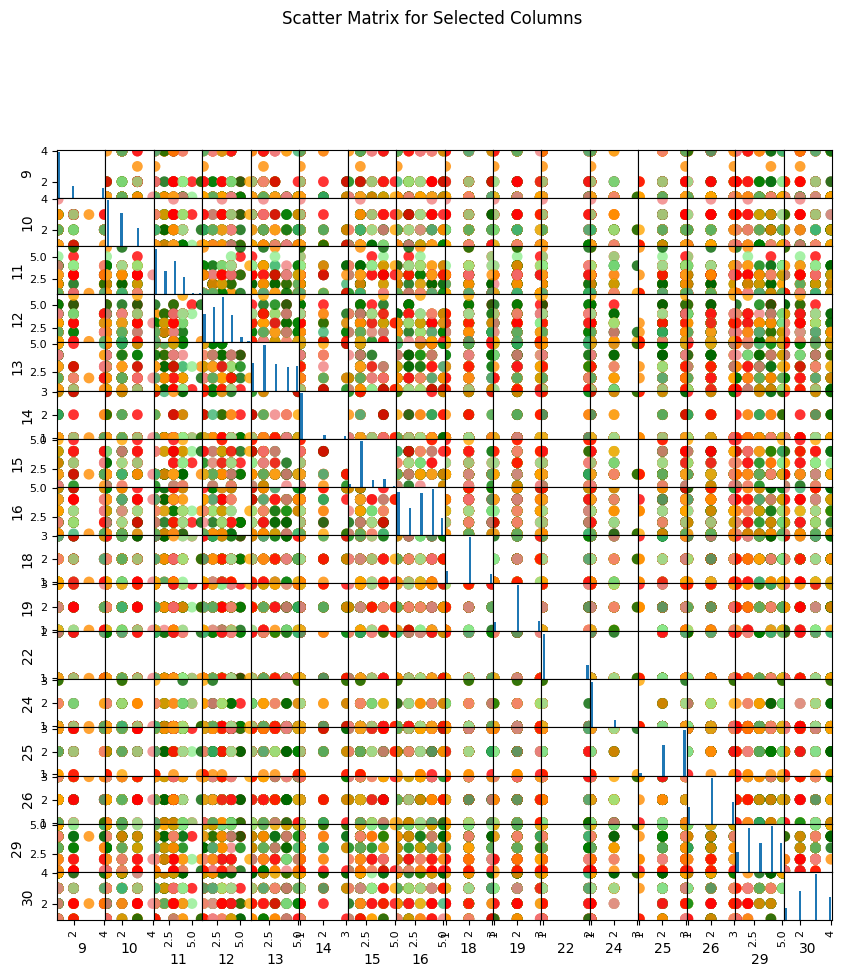

In [5]:
columnas_interesetantes = ['9','10','11','12','13','14','15','16','18','19','22','24','25','26','29','30']
df_particion = df[columnas_interesetantes]

# Definir los colores deseados para cada grado
colors = [
    'red',          # 0: F (Fail)
    'lightcoral',   # 1: DD
    'darkorange',   # 2: DC
    'orange',       # 3: CC
    'lightgreen',   # 4: CB
    'mediumseagreen', # 5: BB
    'green',        # 6: BA
    'darkgreen'     # 7: AA
]

# Crear un mapa de colores personalizado
custom_cmap = ListedColormap(colors)

sp_subset = pd.plotting.scatter_matrix(df_particion, c=df.GRADE, figsize=(10, 10), marker='o',
                                    hist_kwds={'bins': 20}, s=60, alpha=.8, cmap=custom_cmap)
plt.suptitle('Scatter Matrix for Selected Columns', y=1.02) # Add a title to the plot
plt.show()

En este código:

1.  **`selected_columns = ['1', '2', '17', 'GRADE']`**: Defines a list of the column names you want to include.
2.  **`df_subset = df[selected_columns]`**: Creates a new DataFrame `df_subset` containing only the specified columns from your original `df`.
3.  **`pd.plotting.scatter_matrix(df_subset, ...)`**: Passes this `df_subset` to the function, so only those columns will be plotted.

Vamos a calcular y mostrar los coeficientes de correlación de Pearson.

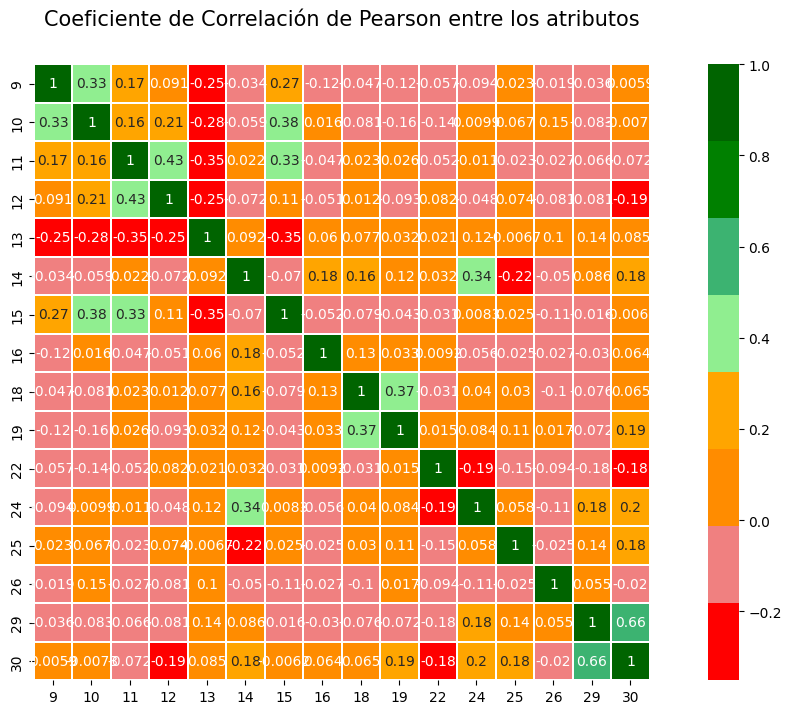

In [6]:
plt.figure(figsize=(15,8))
plt.title('Coeficiente de Correlación de Pearson entre los atributos', y=1.05, size=15)
sns.heatmap(df_particion.astype(float).corr(),linewidths=0.1,vmax=1.0,
            square=True, cmap=custom_cmap, linecolor='white', annot=True)
plt.show()

Observamos que correlación entre pares de atributos que más influyen para estimar la nota del alumno son:

* (0.66): Promedio de notas último semestre / promedio de notas esperado al graduarse
* (0.43): Educación del padre/ Educación de la madre
* (0.38): Ocupación de la madre / Tipo de alojamiento
* (0.37): Frecuencia de lectura no científica / Frecuencia de lectura científica
* (0.34): Cuando empieza a preparar los examenes / Estado civil de los padres
* (0.33): Ocupación de la madre / Educación de la madre
* (0.33): Medio de transporte / Tipo de alojamiento

Es curiso, que con la columna 16 (Ocupación del padre) no se consiguen ninguna correlación, al contrario que con la 15 (Ocupación de la madre).

## Árboles de decisión

Dividimos la base de datos entre conjunto de entrenamiento y conjunto de prueba.

In [7]:
df_data = df.drop(columns=['GRADE','COURSE ID', 'STUDENT ID'])
df_target = df.GRADE

df_train, df_test, df_target_train, df_target_test = \
  train_test_split(df_data,df_target,test_size = 0.25,random_state=2025)


Generamos el árbol de decisión para el conjunto de entrenamiento.

In [28]:
tree3_clf = DecisionTreeClassifier(random_state=10)

tree3_clf.fit(df_train,df_target_train)

DecisionTreeClassifier(random_state=10)

Representamos el árbol obtenido.

In [29]:
model_text = export_text(tree3_clf, feature_names=df_names
)
print(model_text)

|--- Last Semester GPA <= 2.50
|   |--- Transportation <= 1.50
|   |   |--- Scholarship Type <= 2.50
|   |   |   |--- class: 4
|   |   |--- Scholarship Type >  2.50
|   |   |   |--- Project Impact <= 1.50
|   |   |   |   |--- Accommodation Type <= 2.50
|   |   |   |   |   |--- Flip-Classroom <= 1.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Flip-Classroom >  1.50
|   |   |   |   |   |   |--- Accommodation Type <= 1.50
|   |   |   |   |   |   |   |--- Taking Notes <= 2.50
|   |   |   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |   |   |--- Taking Notes >  2.50
|   |   |   |   |   |   |   |   |--- Regular Artistic/Sports Activity <= 1.50
|   |   |   |   |   |   |   |   |   |--- Listening in Class <= 2.00
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |--- Listening in Class >  2.00
|   |   |   |   |   |   |   |   |   |   |--- class: 4
|   |   |   |   |   |   |   |   |--- Regular Artistic/Sports Activity >  1.50
|  

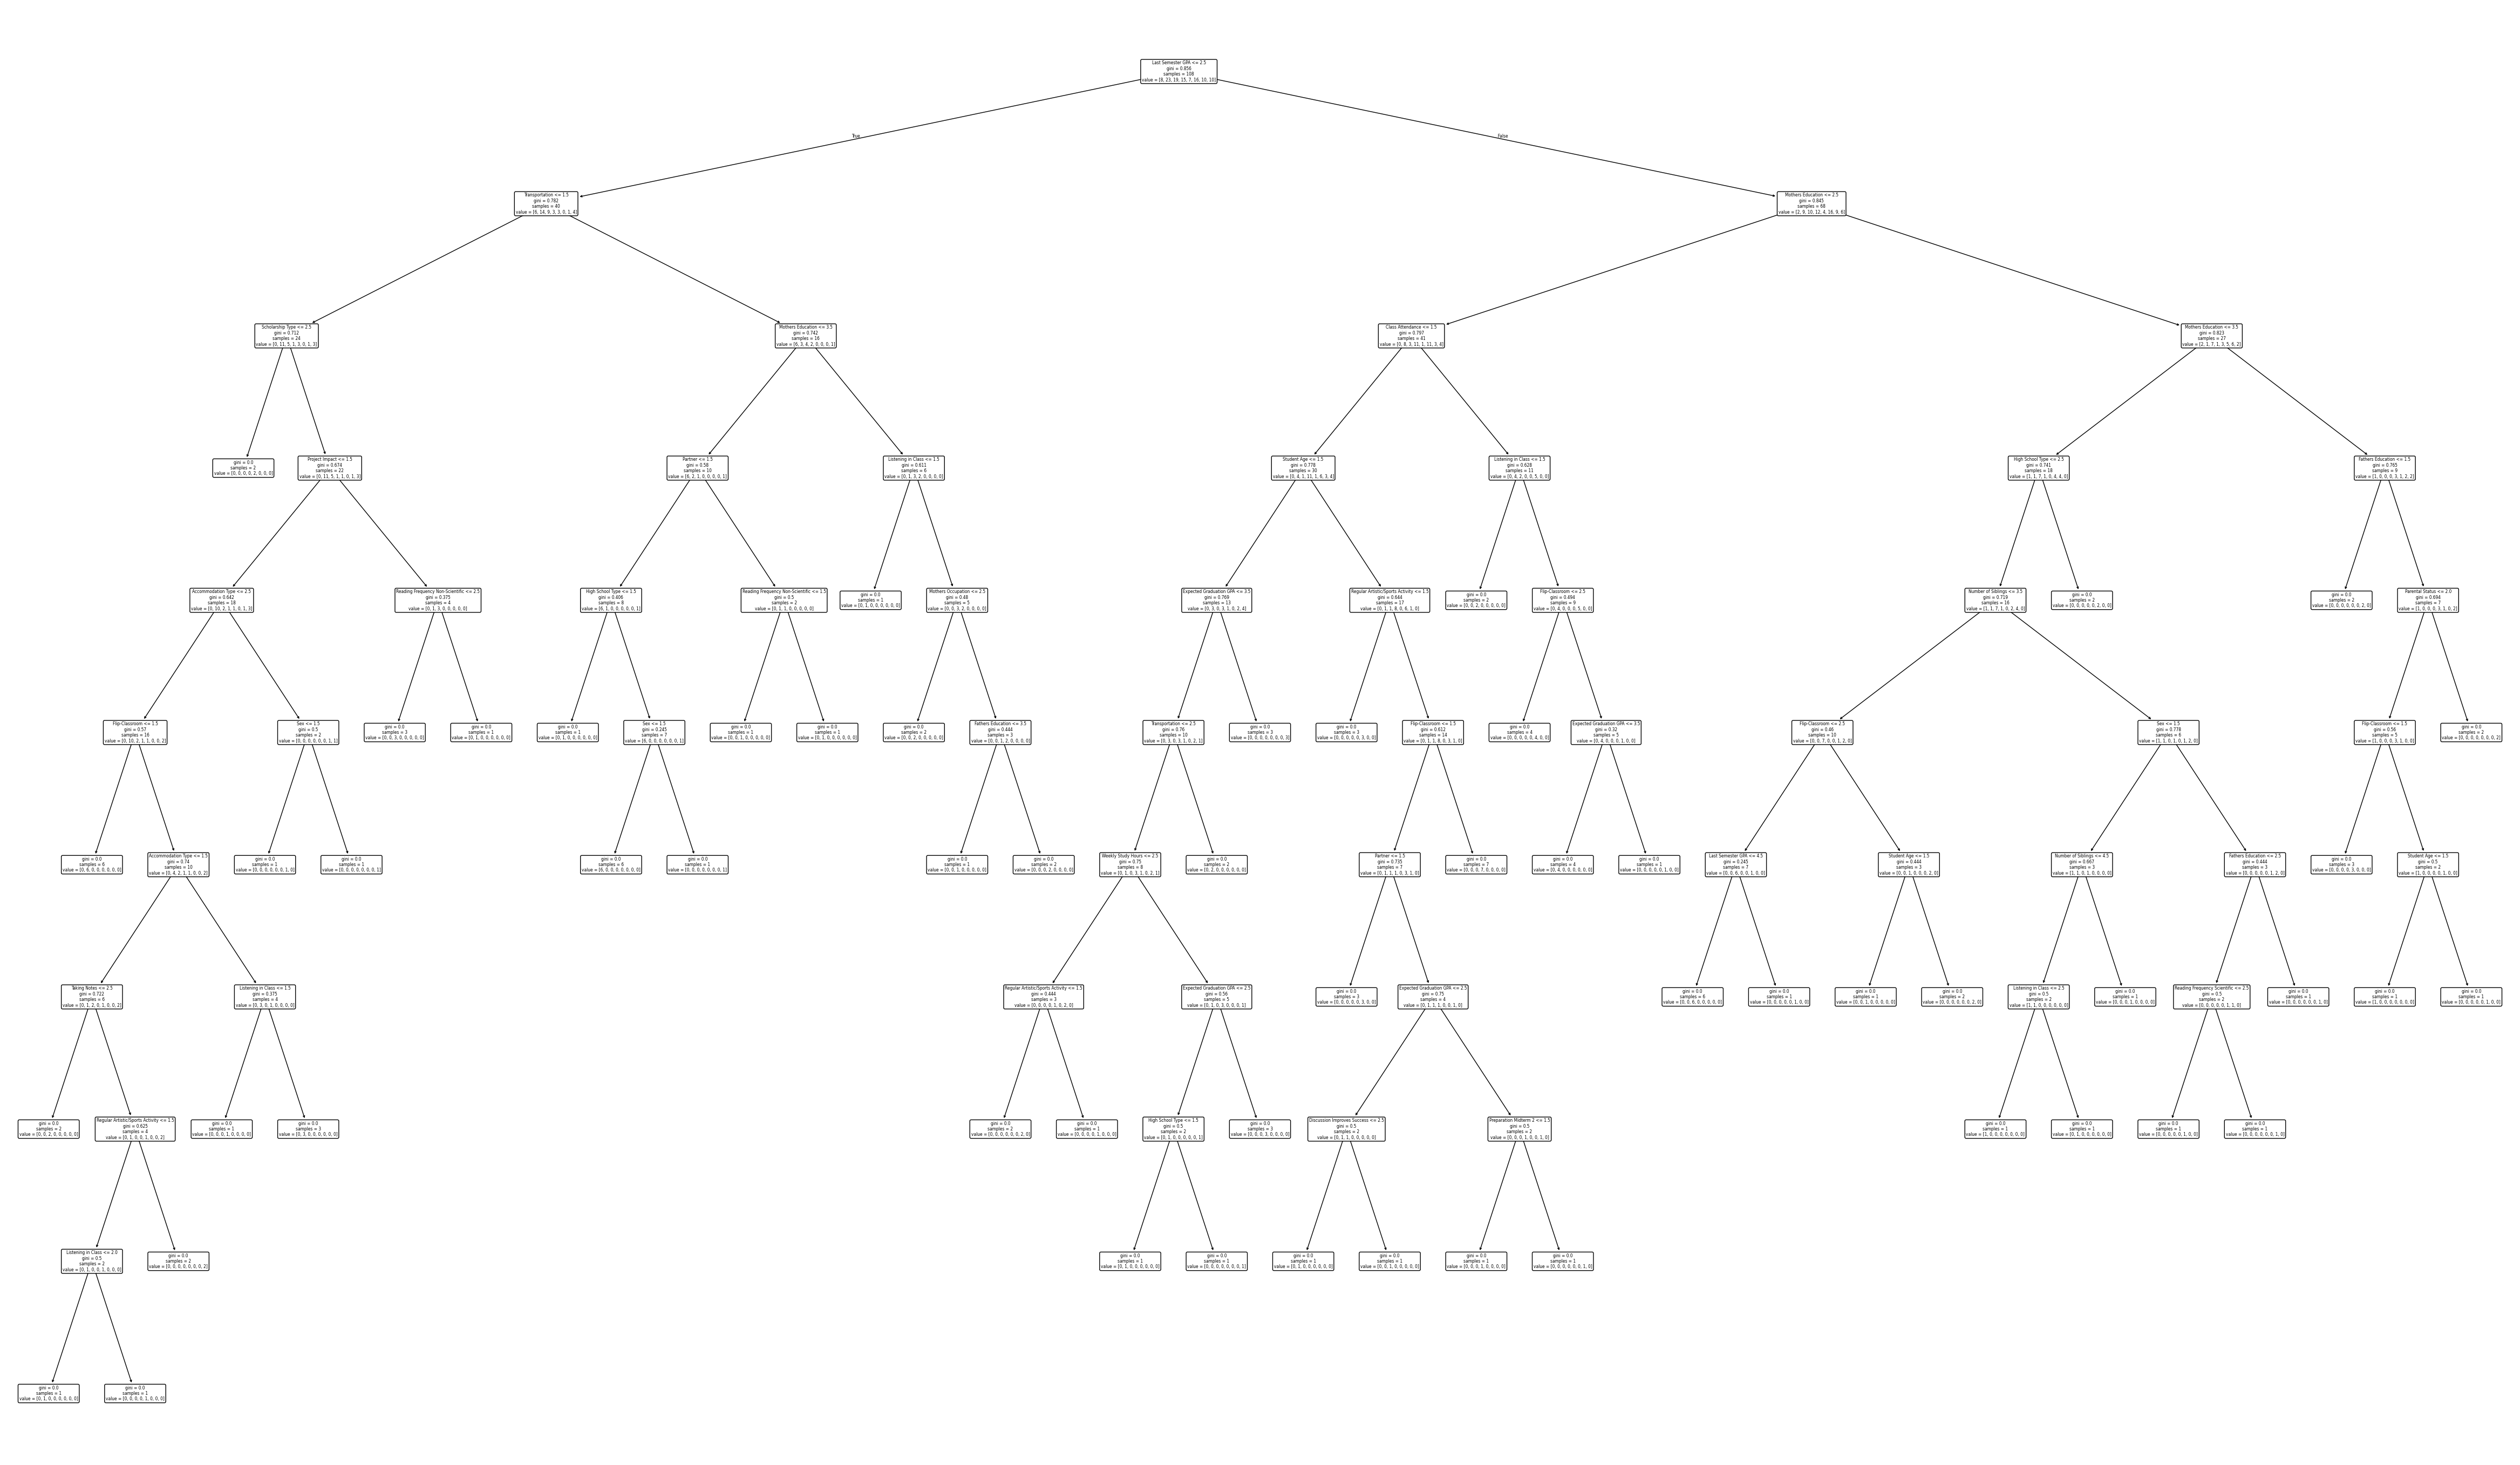

In [30]:
plt.rcParams["figure.figsize"] = [60,35]
plot_tree(tree3_clf,rounded=True,feature_names=df_names)
plt.show()

A continuación calculamos el rendimiento de este modelo en el conjunto de entrenamiento, el conjunto de prueba y el conjunto de datos inicial.

In [31]:
print("Rendimiento en el conjunto de entrenamiento: ",tree3_clf.score(df_train,df_target_train))
print("Rendimiento en el conjunto de prueba: ",tree3_clf.score(df_test,df_target_test))
print("Rendimiento en el conjunto total: ",tree3_clf.score(df_data,df_target))

Rendimiento en el conjunto de entrenamiento:  1.0
Rendimiento en el conjunto de prueba:  0.16216216216216217
Rendimiento en el conjunto total:  0.7862068965517242


Tenemos que para el conjunto de entrenamineto se acierta el 100% de los datos para clasificar (como era de esperar) pero para el conjunto de prueba a penas tenemos el 16%.

Vamos a limitar la profundidad del árbol de decisión para intentar mejorar la clasificación del conjunto de prueba. Para ello, vamos a iterar 20 veces para cada valor de profundidad máxima entre 2 y 9. Y obtener con que valor de profundidad máxima obtenemos mejores resultados en el conjunto de prueba.

In [33]:
random.seed(2025)

rendimientos = []
for i in range(2,12):
  val = 0
  for _ in range(20):
    tree3_clf_2 = DecisionTreeClassifier(max_depth=i)
    tree3_clf_2.fit(df_train,df_target_train)
    val += tree3_clf_2.score(df_test,df_target_test)
  rendimientos.append(val / 20) #acumulamos para cada profundiad i=2,...,11 el rendimiento para el conjunto de prueba

valor_maximo = max(rendimientos)
indice_maximo = rendimientos.index(valor_maximo)
print("Mejor rendimiento del conjunto de prueba conseguido:", valor_maximo, "\nConseguido para la profundidad: ",indice_maximo+2)


Mejor rendimiento del conjunto de prueba conseguido: 0.27567567567567564 
Conseguido para la profundidad:  4


Hemos mejorado el porcentaje de acierto para el conjunto de prueba.

También podemos tratar de mejorarlo, aplicando la técnica de un número mínimo de datos para seguir ramificando. Nuevamente, vamos a iterar 20 veces para cada valor de ramificación entre 2 y 50 para obtener el mejor rendimiento para el conjunto de prueba.

In [34]:
random.seed(2025)

num_tam = 50
iteraciones = 20
means = []

for i in range(2,num_tam):
    val = 0
    for _ in range(iteraciones):
        x_train_aux, x_test_aux, y_train_aux, y_test_aux = train_test_split(df_data, df_target, test_size=0.25)
        tree_aux = DecisionTreeClassifier(min_samples_split=i)
        tree_aux.fit(x_train_aux, y_train_aux)
        val += skm.accuracy_score(y_test_aux, tree_aux.predict(x_test_aux))
    m = val / iteraciones
    means.append(m)

valor_maximo = max(means)
indice_maximo = means.index(valor_maximo)
print("Mejor rendimiento del conjunto de prueba conseguido:", valor_maximo, "\nConseguido para la ramificación máxima: ",indice_maximo+2)

Mejor rendimiento del conjunto de prueba conseguido: 0.25540540540540546 
Conseguido para la ramificación máxima:  43


Aunque hemos superado el valor obtenido originalmente, sin aplicar ninguna restricción en el árbol, no hemos mejorado el caso de restricciones sobre profundidad. Por ello, vamos a combinar ramificación con profundidad, para intentar obtener mejores resultados combinando ambas técnicas.

Para e

In [35]:
random.seed(2025)

num_tam = 50
iteraciones = 20
means = []

for rami in range(2,num_tam):
  for prof in range(2,12):
    val = 0
    for _ in range(iteraciones):
        x_train_aux, x_test_aux, y_train_aux, y_test_aux = train_test_split(df_data, df_target, test_size=0.25)
        tree_aux = DecisionTreeClassifier(min_samples_split=rami, max_depth=prof)
        tree_aux.fit(x_train_aux, y_train_aux)
        val += skm.accuracy_score(y_test_aux, tree_aux.predict(x_test_aux))
    m = val / iteraciones
    means.append((m,rami,prof))

# Encontrar el valor máximo de 'm' y sus rami y prof asociados
mejor_rendimiento_tupla = max(means, key=lambda item: item[0])
valor_maximo = mejor_rendimiento_tupla[0]
rami_maximo = mejor_rendimiento_tupla[1]
prof_maxima = mejor_rendimiento_tupla[2]

print(f"Mejor rendimiento del conjunto de prueba conseguido: {valor_maximo:.4f}\nConseguido para la ramificación máxima: {rami_maximo}\nConseguido para la profundidad máxima: {prof_maxima}")

Mejor rendimiento del conjunto de prueba conseguido: 0.2730
Conseguido para la ramificación máxima: 43
Conseguido para la profundidad máxima: 10


Veamos la forma que tiene este árbol de decisión.

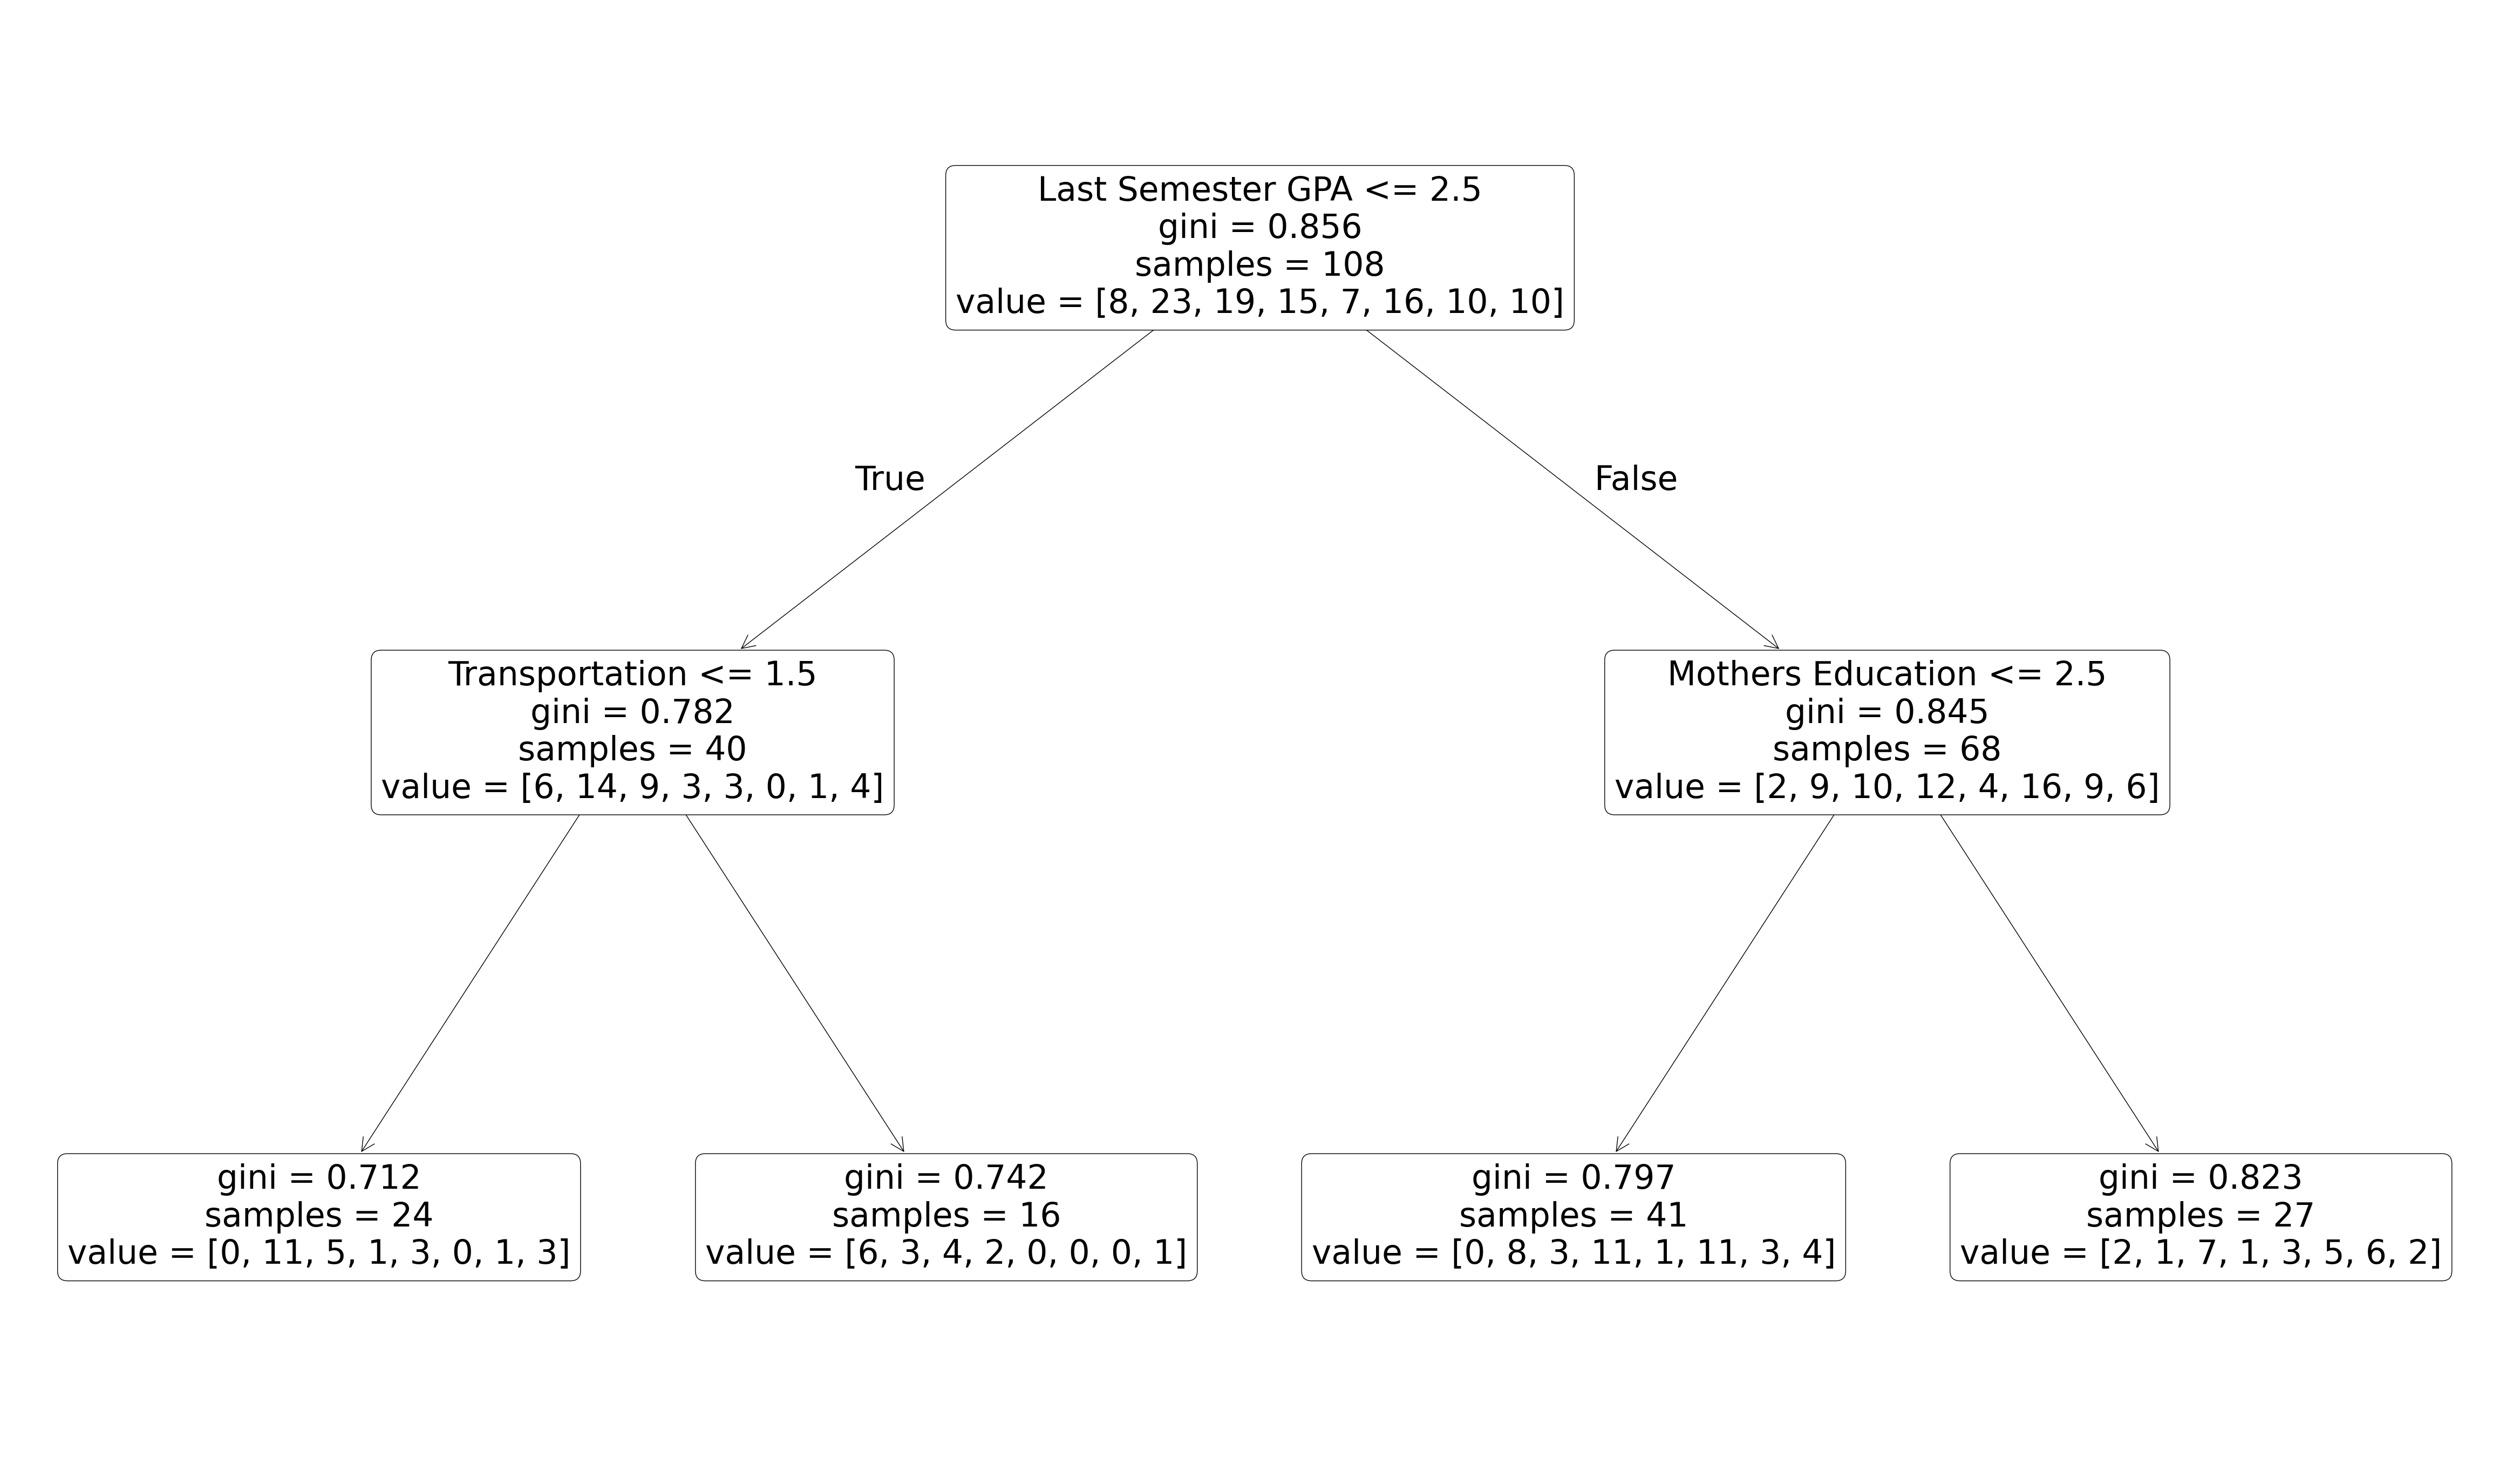

0.2702702702702703

In [36]:
tree_aux = DecisionTreeClassifier(min_samples_split=20, max_depth=2)

tree_aux.fit(df_train,df_target_train)

plt.rcParams["figure.figsize"] = [60,35]
plot_tree(tree_aux,rounded=True,feature_names=df_names)
plt.show()

skm.accuracy_score(df_target_test, tree_aux.predict(df_test))

Hemos conseguido un porcentaje de acierto para el conjunto de prueba del 28.65%



---



## 2º Parte

Vamos a aplicar nuevas técnicas para tratar de aumentar el porcentaje de acierto del conjunto de prueba.

Vamos a implementar *stratify=df_target* en el train_test_split para equilibrar la proporción de los valores de *df_target=GRADE* para el conjunto de prueba.

In [37]:
random.seed(2025)

num_tam = 50
iteraciones = 20
means = []

for rami in range(2,num_tam):
  for prof in range(2,12):
    val = 0
    for _ in range(iteraciones):
        df_train, df_test, df_target_train, df_target_test = \
    train_test_split(df_data, df_target, test_size=0.25,
                     random_state=2025, stratify=df_target)
        tree_aux = DecisionTreeClassifier(min_samples_split=rami, max_depth=prof)
        tree_aux.fit(x_train_aux, y_train_aux)
        val += skm.accuracy_score(y_test_aux, tree_aux.predict(x_test_aux))
    m = val / iteraciones
    means.append((m,rami,prof))

# Encontrar el valor máximo de 'm' y sus rami y prof asociados
mejor_rendimiento_tupla = max(means, key=lambda item: item[0])
valor_maximo = mejor_rendimiento_tupla[0]
rami_maximo = mejor_rendimiento_tupla[1]
prof_maxima = mejor_rendimiento_tupla[2]

print(f"Mejor rendimiento del conjunto de prueba conseguido: {valor_maximo:.4f}\nConseguido para la ramificación máxima: {rami_maximo}\nConseguido para la profundidad máxima: {prof_maxima}")

Mejor rendimiento del conjunto de prueba conseguido: 0.1905
Conseguido para la ramificación máxima: 3
Conseguido para la profundidad máxima: 7


No hemos conseguido aumentar demasiado. Como el resultado es peor, volvamos a la versión anterior.

Vamos a aplicar ahora ramificación en las hojas con *min_leaf*. Diferencia con *min_samples_split*:
* *min_samples_split*: Controla antes de seguir ramificando si el conjunto de datos que tenemos supera un valor mínimo, en caso contrario no sigue ramificando ese nodo.
* *min_leaf*: Una vez se ha ramificado, comprueba si los conjuntos de datos resultantes superan un valor mínimo, en caso contrario no se realiza la ramificación.

In [38]:
random.seed(2025)

num_tam = 50
iteraciones = 20
means = []

for rami in range(2,num_tam):
  for prof in range(2,12):
    for min_leaf in range(2,12):
      val = 0
      for _ in range(iteraciones):
          df_train, df_test, df_target_train, df_target_test = \
      train_test_split(df_data, df_target, test_size=0.25,
                      random_state=2025, stratify=df_target)
          tree_aux = DecisionTreeClassifier(min_samples_split=rami, max_depth=prof,min_samples_leaf=min_leaf)
          tree_aux.fit(x_train_aux, y_train_aux)
          val += skm.accuracy_score(y_test_aux, tree_aux.predict(x_test_aux))
      m = val / iteraciones
      means.append((m,rami,prof,min_leaf))

# Encontrar el valor máximo de 'm' y sus rami y prof asociados
mejor_rendimiento_tupla = max(means, key=lambda item: item[0])
valor_maximo = mejor_rendimiento_tupla[0]
rami_maximo = mejor_rendimiento_tupla[1]
prof_maxima = mejor_rendimiento_tupla[2]
leaf_maxima = mejor_rendimiento_tupla[3]

print(f"Mejor rendimiento del conjunto de prueba conseguido: {valor_maximo:.4f}\nConseguido para la ramificación máxima: {rami_maximo}\nConseguido para la profundidad máxima: {prof_maxima}\nConseguido para la ramificación en hoja máxima: {prof_maxima}")

Mejor rendimiento del conjunto de prueba conseguido: 0.2973
Conseguido para la ramificación máxima: 2
Conseguido para la profundidad máxima: 4
Conseguido para la ramificación en hoja máxima: 4


Vamos a representar mediante un histograma para ver la distribución de las notas.

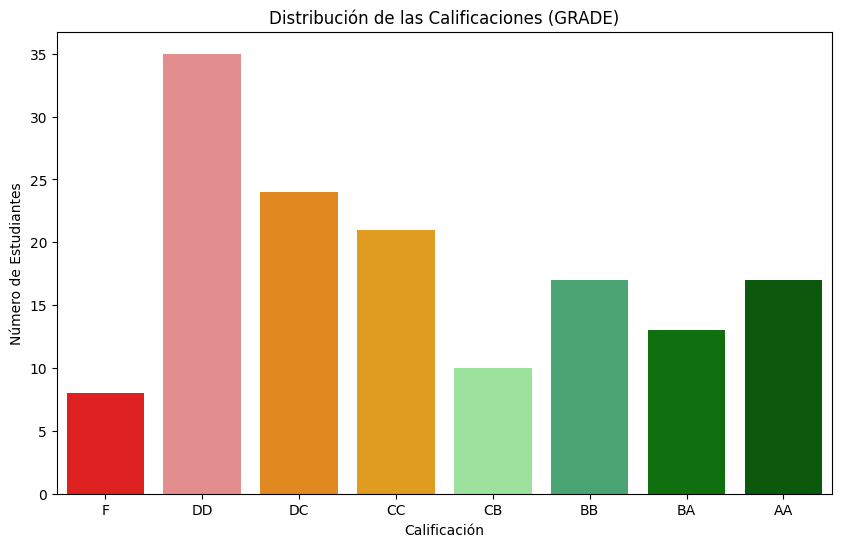

In [10]:
plt.figure(figsize=(10, 6))
# Define the grade labels corresponding to the numerical values 0-7
grade_labels = ['F', 'DD', 'DC', 'CC', 'CB', 'BB', 'BA', 'AA']

# Create a color palette from the custom_cmap
colors_palette = [custom_cmap(i/7) for i in range(8)] # Divide by 7 as GRADE goes from 0 to 7

sns.countplot(x='GRADE', data=df, palette=colors_palette, hue='GRADE', legend=False)
plt.title('Distribución de las Calificaciones (GRADE)')
plt.xlabel('Calificación')
plt.ylabel('Número de Estudiantes')
plt.xticks(ticks=range(len(grade_labels)), labels=grade_labels)
plt.show()

7. Balancear clases con class_weight
Tu dataset probablemente tiene clases desbalanceadas (muchos alumnos con CA, pocos con AA).

9. Análisis de importancia de características (Feature Importance)
Identifica qué características realmente importan:



10. Ingeniería de características: crear nuevas variables
Combina características existentes para crear nuevas señales

Vamos a reorganizar las características que tenemos seleccionadas.

Para ello vamos primero a comprobar cuales son las caracteristicas más influyentes.

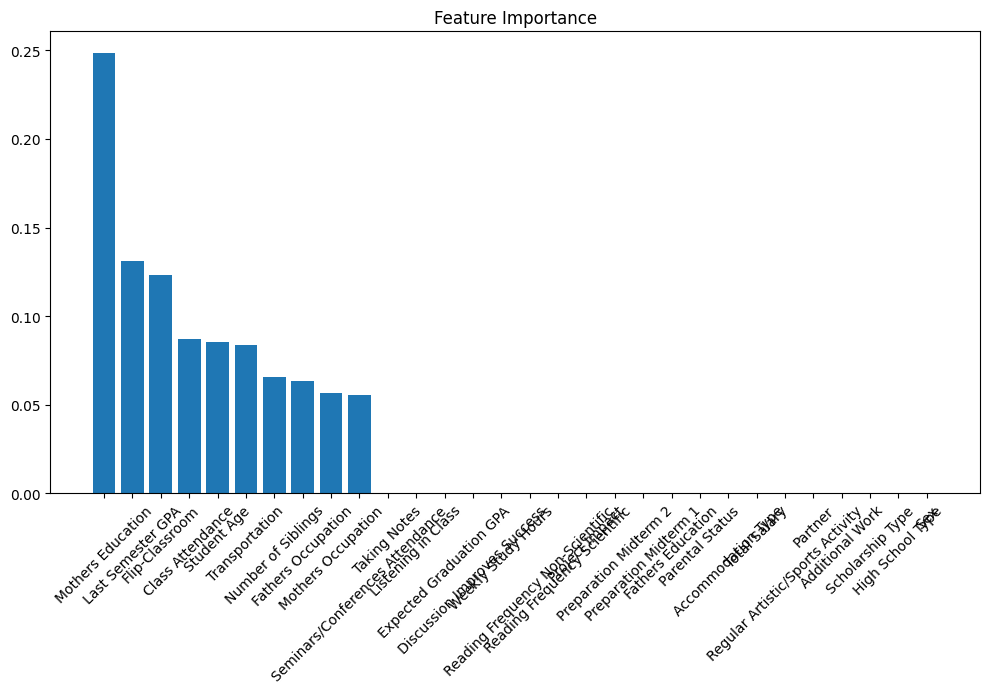

In [15]:
random.seed(2025)

tree = DecisionTreeClassifier(min_samples_split=2, max_depth=4,min_samples_leaf=4)
tree.fit(df_train, df_target_train)

importances = tree.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title('Feature Importance')
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [df_names[i] for i in indices], rotation=45)
plt.show()

# Seleccionar solo top features
top_features_indices = indices[:10]  # Top 15 características
df_data_important = df_data.iloc[:, top_features_indices]


In [17]:
top_features_indices

array([10, 28, 27, 21,  0,  8, 12, 15, 14, 19])

Como segunda parte vamos a unificar 3 caracteristicas, para crear una nueva caracteristica.

Para ello, hemos unido las caracteristicas de tomar notas en calse, escuchar en clase y la asistencia a clase. Vamos a considerar la nueva caracteristica, denotada por compromiso academico, como la suma de las cualidades anteriores que sugieran que el alumno está comprometido por la asignatura

In [16]:
# Crear variable de "engagement académico"
df_data_engineered = df_data.copy()

# Suma de hábitos de estudio positivos
df_data_engineered['academic_engagement'] = (
    df_data['25'] +  # Taking Notes
    df_data['26'] +  # Listening in Class
    df_data['22']    # Class Attendance (invertida: 1=always)
)

# Nivel educativo familiar (promedio de padres)
df_data_engineered['parental_education_avg'] = (
    df_data['11'] + df_data['12']
) / 2

# Preparación para exámenes
df_data_engineered['exam_preparation'] = (
    df_data['23'] + df_data['24']
)


In [ ]:
tree = DecisionTreeClassifier(min_samples_split=2, max_depth=4,min_samples_leaf=4)
tree.fit(x_train_aux, y_train_aux)
skm.accuracy_score(y_test_aux, tree_aux.predict(x_test_aux))